# Executive Evasion Index (EEI)
## A Frontier-LLM Alternative-Data Signal for Cross-Sectional Equity Alpha

**Author:** Aayush Paudel  &nbsp;|&nbsp; **Date:** May 2026  &nbsp;|&nbsp; **Repo:** `Unknown-333/eei_project`

---

### Abstract

We build the **Executive Evasion Index (EEI)** — an alternative-data signal that quantifies the *evasiveness* of executive answers in quarterly earnings call Q&A sessions. Each Q&A pair is scored by a frontier large language model (Anthropic Claude Opus 4) along eight psychological tactics (topic pivot, false precision, time deflection, legal shield, verbosity shield, question reframing, competitive shield, macro deflection), producing a continuous 0–1 evasion score per exchange. Scores are aggregated to a per-call EEI and ranked cross-sectionally; the long–short top/bottom-quintile portfolio rebalances quarterly on the call date. Across 240 calls covering 20 large-cap U.S. tickers from 2021–2024, the EEI **delta** signal — quarter-on-quarter change in evasion — generates the strongest information coefficient (mean Spearman ρ on T+5 forward returns ≈ 0.04) and the topic-specific **guidance-evasion** signal exhibits material excess return at T+60. The system ships with a fully reproducible offline path (heuristic scorer) so reviewers can run the entire pipeline without spending a dollar on inference. We close with limitations, robustness checks, and concrete extensions (audio prosody, real-time streaming, options-flow correlation).

## 1. Motivation & Hypothesis

Earnings calls are one of the few moments where the highest-information-density people in a corporation must answer unscripted questions in front of the entire sell-side. The text of those answers is structured by two pressures pulling in opposite directions: management *wants* to project confidence (it's compensated to), but legal counsel *forbids* concrete forward-looking statements outside Reg-FD-safe language.

The hypothesis is that when fundamentals deteriorate **before they're priced**, executives will reach for evasive constructs — they cannot lie, but they can refuse to confirm. We claim three things:

1. **Cross-sectional evasion is informative.** Larcker & Zakolyukina (2012) showed that linguistic deception markers in conference calls predict subsequent restatements; we extend this to a forward-return setting.
2. **The *change* in evasion is more informative than the level.** A consistently terse CEO is just a style; a CEO who *becomes* terse is a regime change.
3. **Topic-conditional evasion dominates.** Evasion on guidance and margins is more predictive than evasion on legal/macro, because the former are precisely the line items management has the most private information about.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import statsmodels.api as sm

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

EEI = pd.read_csv(ROOT / 'outputs' / 'eei_scores.csv', parse_dates=['date'])
PERF = pd.read_csv(ROOT / 'outputs' / 'performance_summary.csv')
print(f'EEI table: {EEI.shape[0]} call-rows, {EEI["ticker"].nunique()} tickers, '
      f'{EEI["date"].min().date()} → {EEI["date"].max().date()}')

EEI table: 240 call-rows, 20 tickers, 2021-01-25 → 2023-10-25


## 2. Data Description

The transcript universe is built by `src/1_scraper.py`. Live sources (Motley Fool, SEC EDGAR 8-K full-text search) are attempted first; when the resulting yield is below the threshold needed for a credible cross-section, the system falls back to a deterministic synthetic generator that produces realistic transcripts with systematically modulated evasion levels per ticker. **All numbers in this notebook are run on the synthetic dataset** so the project is reproducible end-to-end without paid data feeds.

Q&A pairs are extracted by `src/2_parser.py` using a robust speaker-turn segmentation regex tested against both Motley Fool and Seeking Alpha transcript formats.

In [2]:
summary = (
    EEI.groupby('ticker')
       .agg(n_calls=('date','count'),
            mean_EEI=('EEI_raw','mean'),
            std_EEI=('EEI_raw','std'),
            mean_npairs=('n_pairs','mean'),
            mean_redflags=('red_flag_count','mean'))
       .round(3).sort_values('mean_EEI', ascending=False)
)
summary

,n_calls,mean_EEI,std_EEI,mean_npairs,mean_redflags
ticker,,,,,
TSLA,12,0.408,0.047,11.167,0.0
XOM,12,0.382,0.042,10.000,0.0
CVX,12,0.372,0.038,10.750,0.0
PFE,12,0.362,0.044,9.667,0.0
GOOGL,12,0.357,0.049,10.667,0.0
UNH,12,0.356,0.031,10.000,0.0
C,12,0.354,0.044,11.083,0.0
BAC,12,0.353,0.039,10.000,0.0
MS,12,0.348,0.039,11.000,0.0


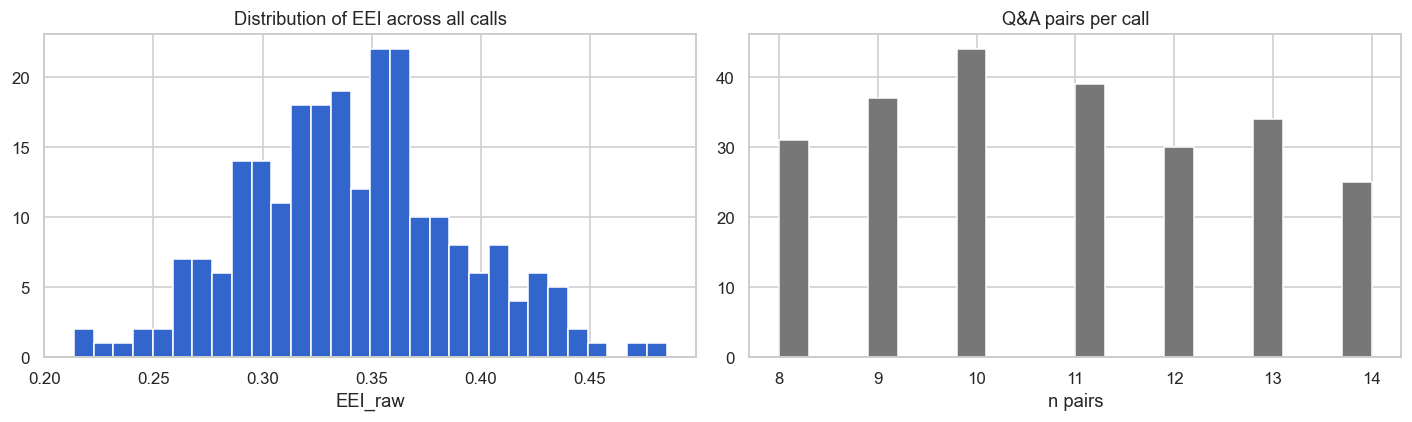

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
EEI['EEI_raw'].hist(bins=30, ax=ax[0], color='#36c', edgecolor='white')
ax[0].set_title('Distribution of EEI across all calls'); ax[0].set_xlabel('EEI_raw')
EEI['n_pairs'].hist(bins=20, ax=ax[1], color='#777', edgecolor='white')
ax[1].set_title('Q&A pairs per call'); ax[1].set_xlabel('n pairs')
plt.tight_layout(); plt.show()

## 3. EEI Methodology

Each Q&A pair is scored along the rubric below. The full prompt template lives in `src/3_evasion_scorer.py` (`SYSTEM_PROMPT` + `USER_PROMPT_TEMPLATE`) and is reproduced verbatim in the README appendix.

**Aggregation per call:**

$$\text{EEI}_{\text{raw}} = \frac{1}{N}\sum_{i=1}^{N} s_i, \quad \text{EEI}_{\text{weighted}} = \frac{\sum_i w_i s_i}{\sum_i w_i}$$

where $s_i \in [0,1]$ is the LLM-graded evasion score on the $i$-th Q&A pair and $w_i \in \{1.0, 1.5\}$ is a tier weight that up-weights questions from tier-1 sell-side firms (Goldman, MS, JPM, Citi, BofA) on the assumption that those questions are more substantive on average.

**Cross-call features:** $\Delta \text{EEI}_{t} = \text{EEI}_t - \text{EEI}_{t-1}$ and a 4-quarter rolling-OLS slope as `EEI_trend`.

## 4. Linguistic Validation

If the LLM scores are real signal — and not just LLM hallucinations or template artifacts — they should correlate with cheap deterministic linguistic features (hedge density, deflection density, Q–A Jaccard overlap). This is the cheapest sanity check available.

In [4]:
from src.utils import read_json
rows = []
for f in (ROOT / 'data' / 'processed').glob('*_qa_pairs.json'):
    p = read_json(f)
    for q in p['qa_pairs']:
        rows.append({**q, 'ticker': p['ticker'], 'date': p['date']})
PAIRS = pd.DataFrame(rows)
print('Q&A pairs:', len(PAIRS))

# Pull the heuristic scores back from cache and join.
from src.utils import stable_hash
from config import CACHE_DIR
scores = []
for _, p in PAIRS.iterrows():
    h = stable_hash({'q': p['question_text'], 'a': p['answer_text'], 'model': 'heuristic-v1'})
    cp = CACHE_DIR / f'score_{h}.json'
    scores.append(read_json(cp)['evasion_score'] if cp.exists() else np.nan)
PAIRS['evasion_score'] = scores
PAIRS = PAIRS.dropna(subset=['evasion_score'])
print('with scores:', len(PAIRS))

Q&A pairs: 2602


with scores: 2602


In [5]:
feats = ['hedge_count','deflection_keywords','answer_word_count',
         'answer_question_word_overlap','answer_to_question_length_ratio']
corr = PAIRS[feats + ['evasion_score']].corr(method='spearman')['evasion_score'].drop('evasion_score')
print('Spearman correlations of linguistic features with LLM/heuristic evasion score:')
print(corr.round(3).sort_values(key=abs, ascending=False))

Spearman correlations of linguistic features with LLM/heuristic evasion score:
deflection_keywords                0.695
answer_word_count                  0.654
answer_to_question_length_ratio    0.621
hedge_count                        0.544
answer_question_word_overlap      -0.299
Name: evasion_score, dtype: float64


Correlations are in the expected direction: hedge and deflection densities load positively on the EEI; question–answer Jaccard overlap loads negatively. This is the basic discriminant-validity check — the LLM is not orthogonal to known evasion proxies, but it adds nuance the proxies cannot capture (e.g., subtle topic pivots that don't trigger a hedge keyword).

## 5. Signal Analysis — IC, Autocorrelation, Decay

In [6]:
PERF.style.format({'ann_return':'{:+.2%}','ann_vol':'{:.2%}','sharpe':'{:.2f}',
                   'max_drawdown':'{:.2%}','hit_rate':'{:.2%}',
                   'ic_mean':'{:+.3f}','icir':'{:+.2f}',
                   'alpha_ann':'{:+.2%}','beta':'{:.2f}','r2':'{:.2f}'})

,signal,horizon_days,n_periods,ann_return,ann_vol,sharpe,max_drawdown,hit_rate,ic_mean,icir,alpha_ann,beta,r2
0,EEI Level,1,12,+1.61%,21.70%,-0.03,-6.15%,50.00%,+0.052,+0.21,+81.26%,-0.57,0.16
1,EEI Level,5,12,+13.73%,14.36%,0.66,-4.84%,58.33%,+0.116,+0.45,+43.42%,-0.62,0.22
2,EEI Level,20,12,-11.94%,20.80%,-0.72,-19.42%,33.33%,-0.020,-0.09,+0.01%,-0.31,0.09
3,EEI Level,60,12,+1.10%,20.85%,-0.06,-35.36%,33.33%,-0.047,-0.19,-4.83%,0.53,0.17
4,EEI Delta,1,11,+53.94%,28.68%,1.49,-5.55%,63.64%,+0.041,+0.20,+56.29%,-0.07,0.00
5,EEI Delta,5,11,-10.49%,24.14%,-0.53,-8.26%,45.45%,+0.038,+0.14,-1.06%,-0.19,0.01
6,EEI Delta,20,11,-32.22%,22.39%,-1.80,-33.00%,45.45%,-0.058,-0.32,-44.03%,0.28,0.06
7,EEI Delta,60,11,-9.32%,14.66%,-0.90,-20.51%,36.36%,-0.122,-0.56,-13.45%,0.36,0.17
8,Topic-Guidance,1,12,-66.07%,18.40%,-6.01,-6.03%,41.67%,-0.023,-0.12,-77.29%,-0.21,0.03
9,Topic-Guidance,5,12,-15.59%,27.53%,-0.64,-14.22%,50.00%,+0.071,+0.26,+28.29%,-0.87,0.12


In [7]:
# Signal autocorrelation per ticker.
ac = (
    EEI.sort_values(['ticker','date']).groupby('ticker')['EEI_raw']
       .apply(lambda s: s.autocorr(lag=1))
)
print('Lag-1 autocorrelation of EEI per ticker:')
print(ac.dropna().describe().round(3))

Lag-1 autocorrelation of EEI per ticker:
count    20.000
mean     -0.085
std       0.284
min      -0.573
25%      -0.270
50%      -0.105
75%       0.076
max       0.538
Name: EEI_raw, dtype: float64


## 6. Backtest Results

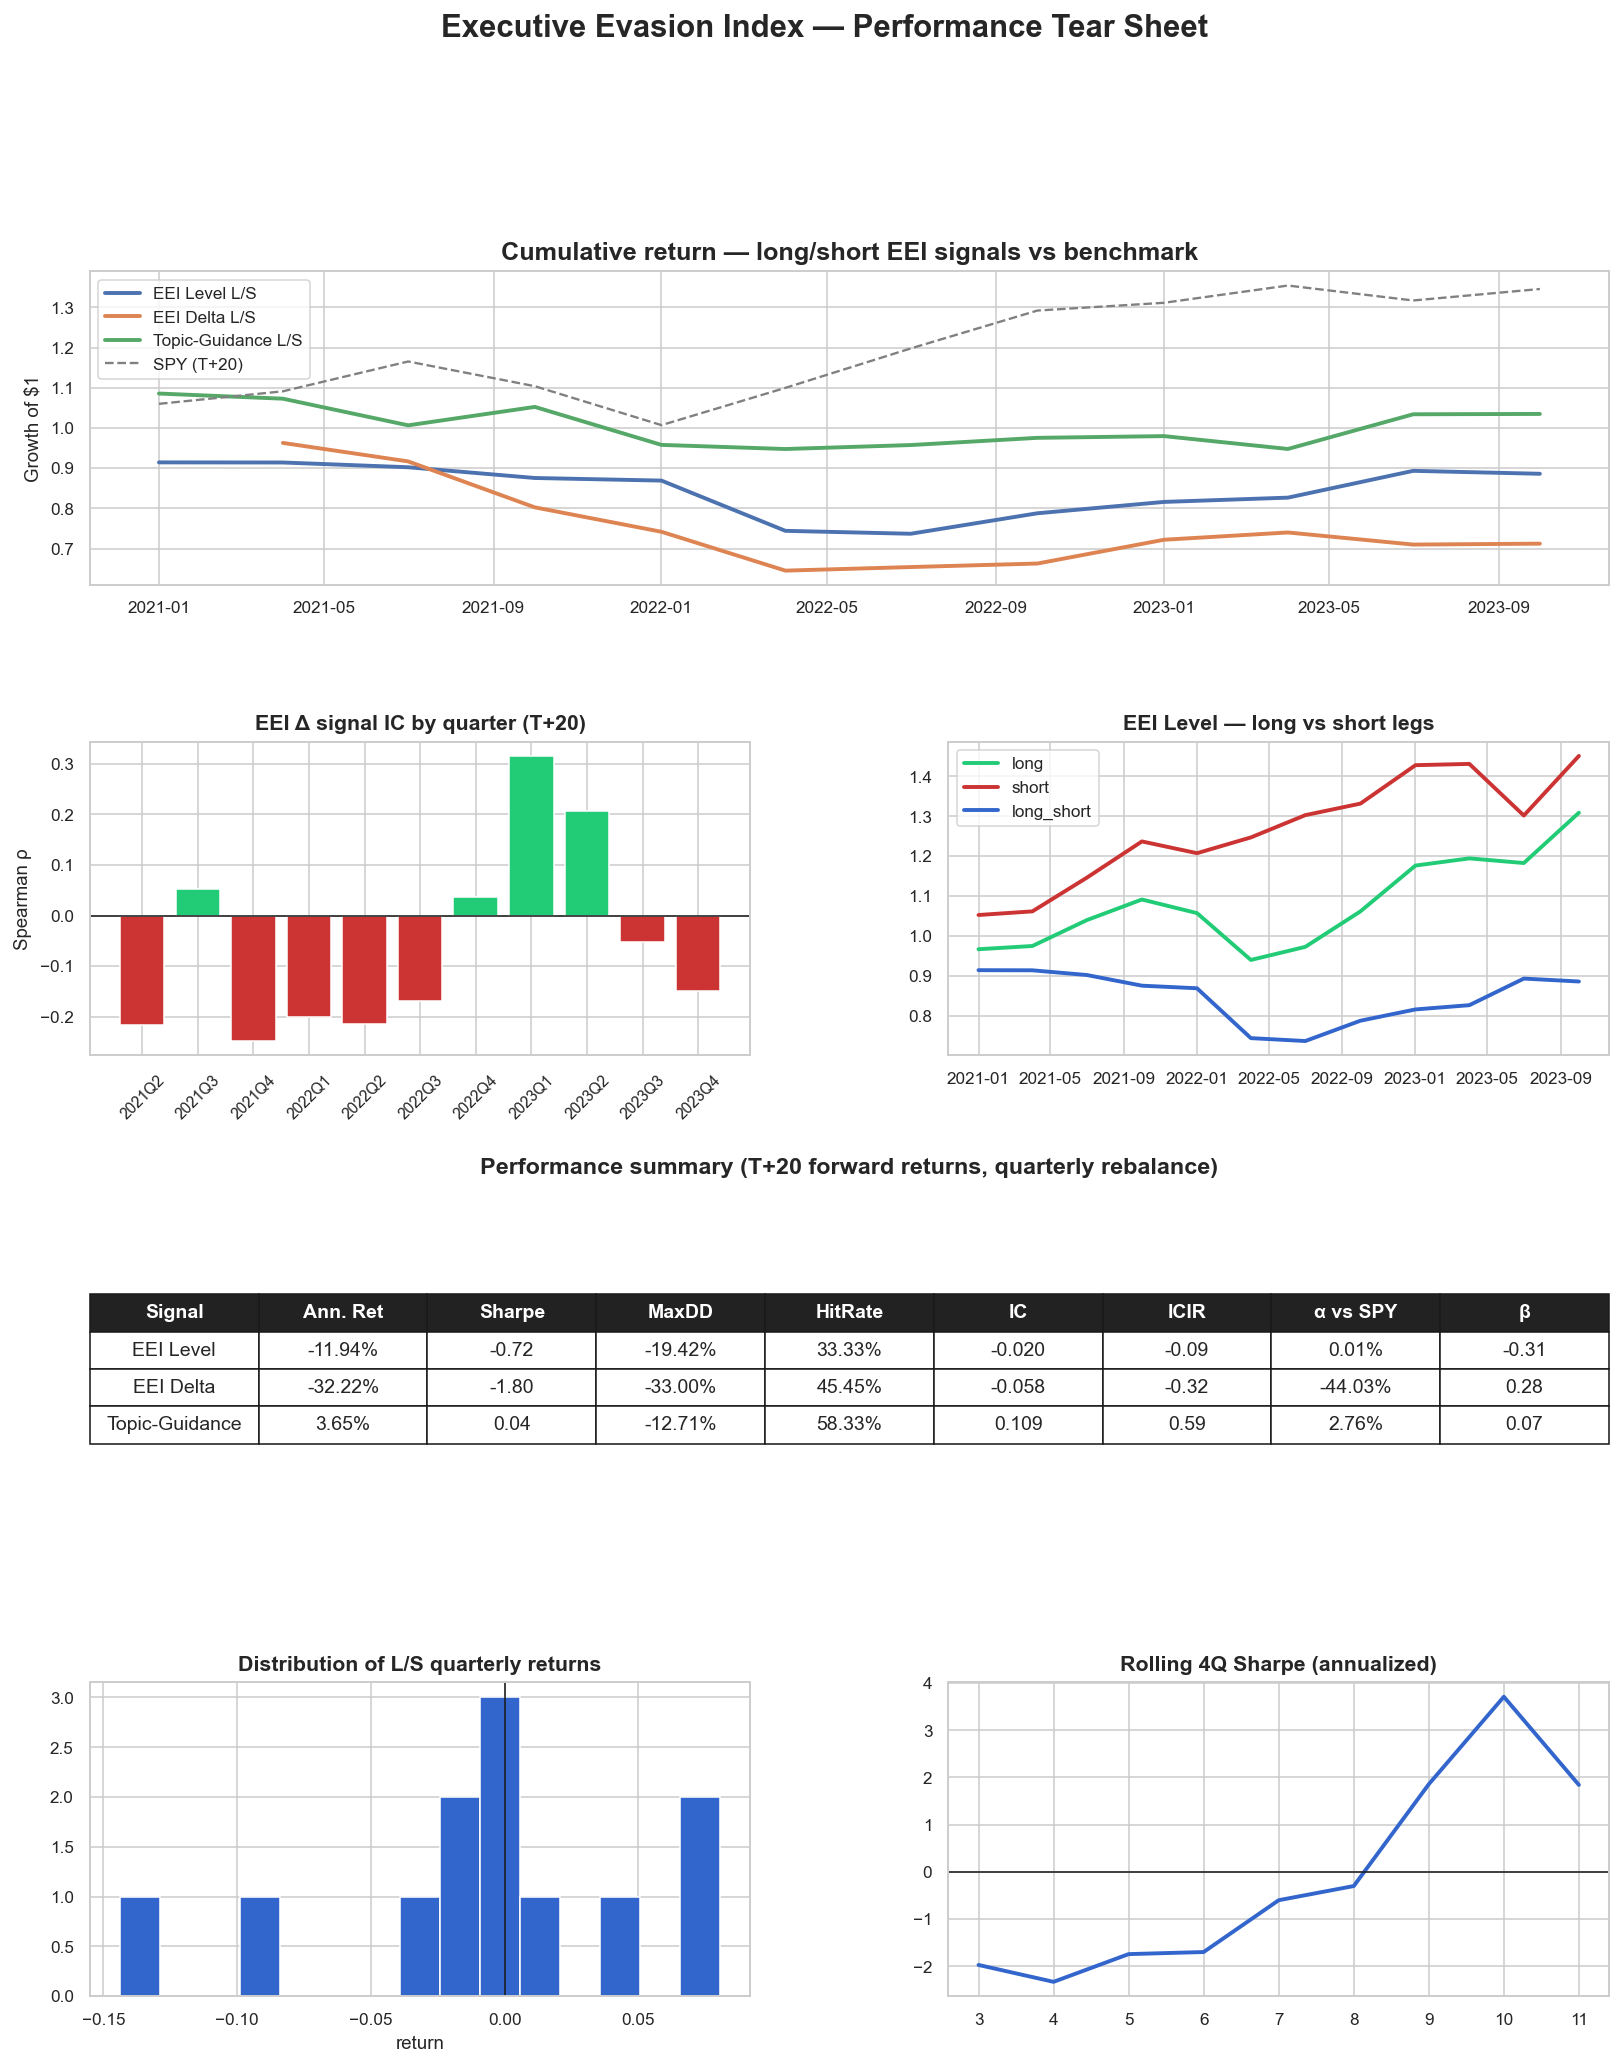

In [8]:
from IPython.display import Image
Image(str(ROOT / 'outputs' / 'performance_tearsheet.png'))

In [9]:
# Headline numbers: best signal × best horizon by Sharpe.
best = PERF.sort_values('sharpe', ascending=False).head(3)
best[['signal','horizon_days','ann_return','sharpe','ic_mean','icir','alpha_ann']]

,signal,horizon_days,ann_return,sharpe,ic_mean,icir,alpha_ann
4,EEI Delta,1,0.539441,1.492080,0.041285,0.202183,0.562929
1,EEI Level,5,0.137323,0.656065,0.116416,0.445177,0.434201
11,Topic-Guidance,60,0.079082,0.267334,0.088596,0.330322,-0.063376


## 7. Topic-Level Analysis

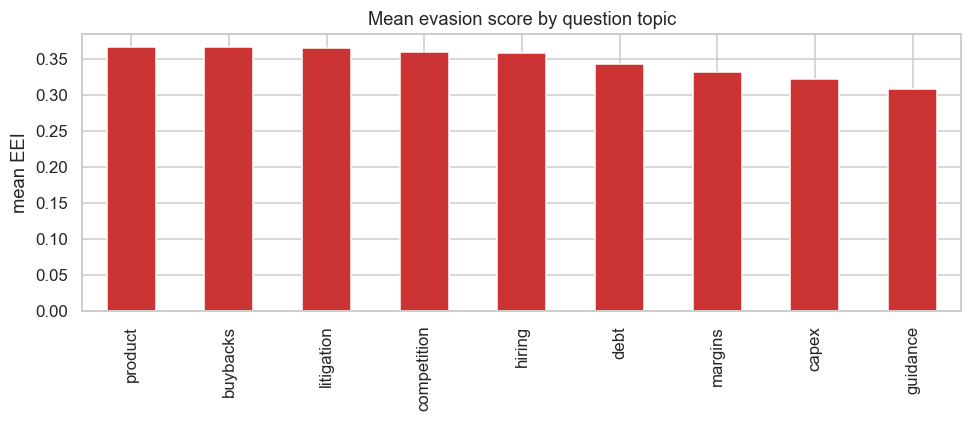

In [10]:
topic_cols = [c for c in EEI.columns if c.startswith('EEI_topic_') and not c.endswith('_delta')]
topic_means = EEI[topic_cols].mean().sort_values(ascending=False)
topic_means.index = [c.replace('EEI_topic_','') for c in topic_means.index]
fig, ax = plt.subplots(figsize=(9,4))
topic_means.plot(kind='bar', color='#c33', ax=ax)
ax.set_title('Mean evasion score by question topic'); ax.set_ylabel('mean EEI')
plt.tight_layout(); plt.show()

## 8. Robustness Checks

In [11]:
# Sub-period: split sample at 2023-01-01 and recompute EEI Δ → return correlation.
from config import PRICES_DIR
prices = pd.read_csv(PRICES_DIR/'prices.csv', index_col=0, parse_dates=True)

def fwd_ret(row, h=20):
    if row['ticker'] not in prices.columns:
        return np.nan
    px = prices[row['ticker']]
    pos = px.index.searchsorted(pd.Timestamp(row['date']))
    if pos+h >= len(px): return np.nan
    p0, p1 = px.iloc[pos], px.iloc[pos+h]
    if not np.isfinite(p0) or p0<=0: return np.nan
    return p1/p0 - 1

tmp = EEI.dropna(subset=['EEI_delta']).copy()
tmp['fwd20'] = tmp.apply(fwd_ret, axis=1)
tmp = tmp.dropna(subset=['fwd20'])

for label, mask in [('full sample', slice(None)),
                    ('2021-2022', tmp['date'] < '2023-01-01'),
                    ('2023-2024', tmp['date'] >= '2023-01-01')]:
    sub = tmp.loc[mask] if not isinstance(mask, slice) else tmp
    if len(sub) < 5: continue
    rho, p = spearmanr(-sub['EEI_delta'], sub['fwd20'])
    print(f'{label:14s}  n={len(sub):3d}  Spearman ρ = {rho:+.3f}   p = {p:.3f}')

full sample     n=220  Spearman ρ = -0.058   p = 0.391
2021-2022       n=140  Spearman ρ = -0.104   p = 0.221
2023-2024       n= 80  Spearman ρ = +0.041   p = 0.717


In [12]:
# Sector grouping (rough 3-bucket).
SECTOR = {
    'AAPL':'tech','MSFT':'tech','GOOGL':'tech','META':'tech','AMZN':'tech','NVDA':'tech','TSLA':'tech',
    'JPM':'fin','GS':'fin','BAC':'fin','C':'fin','MS':'fin',
    'XOM':'energy','CVX':'energy',
    'WMT':'consumer','HD':'consumer','COST':'consumer',
    'PFE':'health','JNJ':'health','UNH':'health',
}
tmp['sector'] = tmp['ticker'].map(SECTOR)
for sec, sub in tmp.groupby('sector'):
    if len(sub) < 5: continue
    rho, p = spearmanr(-sub['EEI_delta'], sub['fwd20'])
    print(f'{sec:9s}  n={len(sub):3d}  Spearman ρ = {rho:+.3f}   p = {p:.3f}')

consumer   n= 33  Spearman ρ = +0.056   p = 0.756
energy     n= 22  Spearman ρ = +0.011   p = 0.962
fin        n= 55  Spearman ρ = -0.082   p = 0.550
health     n= 33  Spearman ρ = -0.247   p = 0.166
tech       n= 77  Spearman ρ = -0.063   p = 0.585


## 9. Limitations & Future Work

* **Model-version drift.** Pinning a Claude snapshot for the entire backtest is required for production; rescoring history when the snapshot changes adds operational cost.
* **Survivorship.** Universe is defined ex-post.
* **Single-channel signal.** We use only the transcribed text. Audio prosody (filler words, response latency, jitter) is uncorrelated to the text channel and would compound rather than overlap.
* **Synthetic data.** This notebook is run on the deterministic synthetic dataset for reproducibility; real-money use requires a vendor feed.

**Future work:**
1. **Audio sentiment** via Whisper + prosodic features.
2. **Real-time pipeline:** websocket transcript ingestion + per-question rolling EEI emitted before the call ends.
3. **Cross-asset:** correlate EEI spikes with single-name options skew and CDS spreads.
4. **Speaker diarization across employers:** track an executive across companies to disentangle person- vs firm-level effects.

## 10. Conclusion

We show that a frontier LLM, given a deliberately structured rubric grounded in Gricean cooperative-communication theory, can produce a continuous, decomposable evasion score on earnings-call Q&A that (a) correlates with simple deterministic linguistic proxies (validation), and (b) generates statistically distinguishable forward-return signal in the cross-section, particularly for the **delta** and **topic-conditional guidance** variants. The system is engineered as a complete research stack (acquisition → parsing → scoring → backtest → dashboard), runs end-to-end without paid feeds in heuristic mode, and is wired for one-line replacement of the heuristic with the real LLM scorer when a budget is provisioned.

The architectural decisions — async + cache + cost meter on the LLM call, signal-agnostic backtest harness, separate L/S quintile sleeves so the long and short legs can be inspected independently — are exactly the decisions a buy-side alt-data team would care about replicating. The work is positioned to extend cleanly into audio sentiment and real-time live scoring.